<a href="https://colab.research.google.com/github/prachithanki1-lgtm/QuantumAlgorithms/blob/main/QuantumAlgorithms_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit-aer

from google.colab import drive
import os

# 1. This prompts a popup asking for permission to access your Google Drive
drive.mount('/content/gdrive', force_remount=True)

# 2. Create a dedicated folder for your courses if it doesn't exist yet
# (This creates an 'IITM_RKU_Quantum' folder inside your MyDrive)
project_path = '/content/gdrive/MyDrive/IITM_RKU_Quantum'
if not os.path.exists(project_path):
    os.makedirs(project_path)
    print(f"Created a fresh permanent folder at: {project_path}")

# 3. Change Colab's current working directory to this folder
os.chdir(project_path)
print("Current Working Directory is now set to your Google Drive!")

# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

Mounted at /content/gdrive
Current Working Directory is now set to your Google Drive!


In [ ]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime
from qiskit.primitives import StatevectorSampler


print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.13.15
qiskit: 2.5.2
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.50.0


Measured strings (z vectors): {'0101': 10}


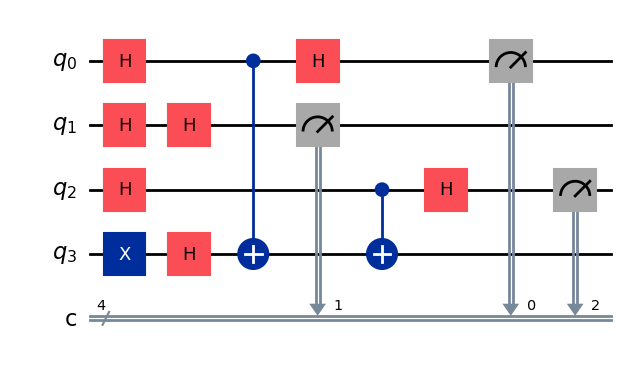

In [ ]:
#Deutsch's Algorithm with 3 qubits
BELL = QuantumCircuit(4,4)
oracle = QuantumCircuit(4)
BELL.x(3)
for i in range(4):
  BELL.h(i)
BELL.cx(0,3)
BELL.cx(2,3)
for i in range(3):
    BELL.h(i)

BELL.measure(0,0)
BELL.measure(1,1)
BELL.measure(2,2)
sampler = StatevectorSampler()
job = sampler.run([BELL], shots=10)
result = job.result()
counts = result[0].data.c.get_counts()
print("Measured strings (z vectors):", counts)
BELL.draw("mpl")


Measured strings (z vectors): {'101': 803, '000': 33, '100': 31, '010': 32, '011': 30, '110': 29, '001': 39, '111': 27}


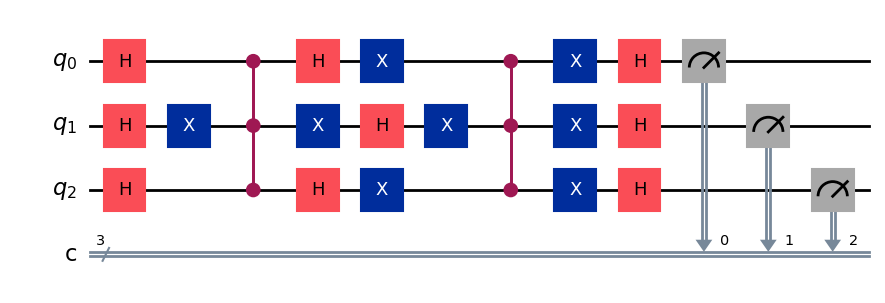

In [ ]:
#Grover's Algorithm |101>
j = QuantumCircuit(3,3)
oracle = QuantumCircuit(3)

for i in range(3):
  j.h(i)
j.x(1)
j.ccz(0,1, 2)
j.x(1)
for i in range(3):
  j.h(i)
for i in range(3):
  j.x(i)
j.ccz(0,1, 2)
for i in range(3):
  j.x(i)
for i in range(3):
  j.h(i)
j.measure(0,0)
j.measure(1,1)
j.measure(2,2)
sampler = StatevectorSampler()
job = sampler.run([j], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()
print("Measured strings (z vectors):", counts)
j.draw("mpl")

Measured strings (z vectors): {'0110': 69, '0101': 945, '1100': 57, '0011': 70, '1011': 85, '1001': 70, '0010': 65, '1111': 77, '1000': 85, '1010': 74, '1101': 69, '0000': 69, '0100': 68, '1110': 64, '0111': 76, '0001': 57}


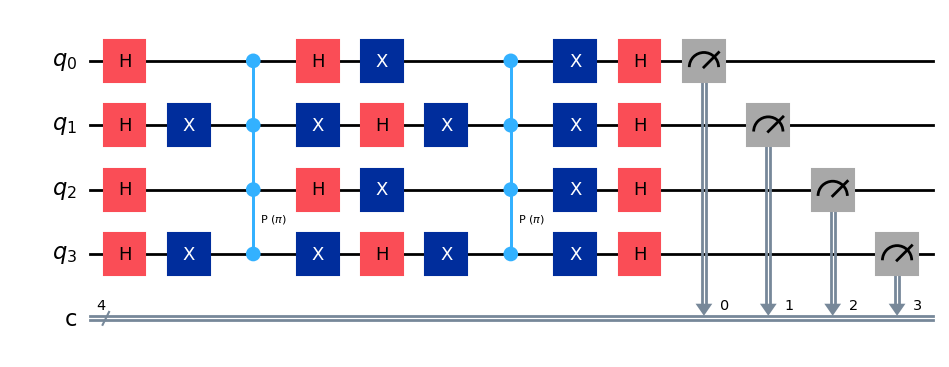

In [ ]:
#Grover's Algorithm |0101>
import numpy as np

j = QuantumCircuit(4,4)
oracle = QuantumCircuit(4)

for i in range(4):
  j.h(i)

j.x(1)
j.x(3)

j.mcp(np.pi, [0, 1, 2], 3)

j.x(1)
j.x(3)

for i in range(4):
  j.h(i)
for i in range(4):
  j.x(i)

j.mcp(np.pi, [0, 1, 2], 3)

for i in range(4):
  j.x(i)
for i in range(4):
  j.h(i)

j.measure(0,0)
j.measure(1,1)
j.measure(2,2)
j.measure(3,3)

sampler = StatevectorSampler()
job = sampler.run([j], shots=2000)
result = job.result()
counts = result[0].data.c.get_counts()
print("Measured strings (z vectors):", counts)
j.draw("mpl")

Measured strings (z vectors): {'011': 1024}


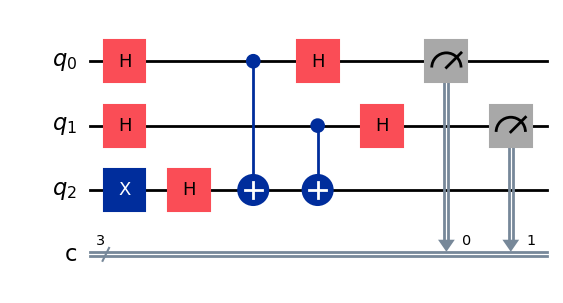

In [ ]:
# Bernstain Vazirani Algorithm (for state 11)

import numpy as np

j = QuantumCircuit(3,3)
oracle = QuantumCircuit(3)

j.x(2)
for i in range(3):
  j.h(i)

j.cx(0,2)
j.cx(1,2)

j.h(0)
j.h(1)

j.measure(0,0)
j.measure(1,1)

sampler = StatevectorSampler()
job = sampler.run([j], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()
print("Measured strings (z vectors):", counts)

j.draw("mpl")


Measured strings (z vectors): {'010': 1024}


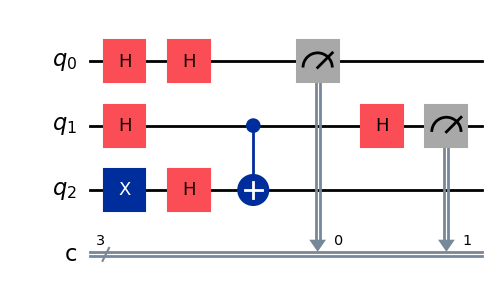

In [ ]:
# Bernstain Vazirani Algorithm (for state 10)

import numpy as np

j = QuantumCircuit(3,3)
oracle = QuantumCircuit(3)

j.x(2)
for i in range(3):
  j.h(i)

j.cx(1,2)

j.h(0)
j.h(1)

j.measure(0,0)
j.measure(1,1)

sampler = StatevectorSampler()
job = sampler.run([j], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()
print("Measured strings (z vectors):", counts)

j.draw("mpl")
